# Задание 1: Аналитика добычи нефти
**Цель:** Построить аналитические витрины добычи и визуализировать KPI по скважинам.

## 1. Импорты и подключение

In [1]:
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from minio import Minio
import pyarrow.parquet as pq

MINIO_ENDPOINT = 'minio:9000'
MINIO_ACCESS   = 'minioadmin'
MINIO_SECRET   = 'minioadmin123'
MINIO_BUCKET   = 'oil-pipeline'

client = Minio(MINIO_ENDPOINT, access_key=MINIO_ACCESS,
               secret_key=MINIO_SECRET, secure=False)
print('MinIO client connected.')

MinIO client connected.


## 2. Загрузка данных из MinIO

In [2]:
def read_parquet_from_minio(prefix: str) -> pd.DataFrame:
    """Читает все parquet-файлы по префиксу и объединяет в один DataFrame."""
    objects = list(client.list_objects(MINIO_BUCKET, prefix=prefix, recursive=True))
    dfs = []
    for obj in objects:
        if obj.object_name.endswith('.parquet'):
            response = client.get_object(MINIO_BUCKET, obj.object_name)
            buf = io.BytesIO(response.read())
            dfs.append(pq.read_table(buf).to_pandas())
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()


df_prod  = read_parquet_from_minio('raw/production/')
df_wells = read_parquet_from_minio('raw/wells/')

df_prod['date'] = pd.to_datetime(df_prod['date'])
df = df_prod.merge(df_wells[['well_id', 'name', 'field_name', 'region', 'status']],
                   on='well_id', how='left')

print(f'Загружено: {len(df)} строк')
df.head()

Загружено: 150 строк


,prod_id,well_id,date,oil_ton,gas_m3,water_m3,energy_kwh,downtime_hours,temperature,pressure,name,field_name,region,status
0,1,1,2025-10-01,212.4,55200.0,182.3,7450.0,0.5,88.1,120.4,Well-101,Severo-Ural,Khanty-Mansi,active
1,31,2,2025-10-01,186.1,49800.0,162.0,6800.0,0.8,84.5,115.4,Well-102,Severo-Ural,Khanty-Mansi,active
2,61,3,2025-10-01,121.8,40120.0,121.5,5280.0,2.0,79.4,107.1,Well-203,Vostok-Field,Yamalo-Nenets,maintenance
3,91,4,2025-10-01,0.0,0.0,0.0,0.0,24.0,NaN,NaN,Well-304,Zapad-Field,Tomsk,suspended
4,121,5,2025-10-01,197.2,52050.0,165.3,7200.0,0.4,86.5,118.8,Well-305,Zapad-Field,Tomsk,active


## 3. Очистка данных

In [3]:
print('Пропуски до очистки:')
print(df.isnull().sum())

# Скважина Well-304 (suspended) — нулевые значения, не аномалия
df_active = df[df['status'] != 'suspended'].copy()

# Заполняем NULL температуры и давления медианой по скважине
for col in ['temperature', 'pressure']:
    df_active[col] = df_active.groupby('well_id')[col].transform(
        lambda x: x.fillna(x.median())
    )

# Фильтрация выбросов (IQR)
def remove_outliers(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    return df[(df[col] >= q1 - 1.5*iqr) & (df[col] <= q3 + 1.5*iqr)]

before = len(df_active)
df_clean = remove_outliers(df_active, 'oil_ton')
print(f'\nОтфильтровано выбросов: {before - len(df_clean)}')
print(f'Строк после очистки: {len(df_clean)}')

Пропуски до очистки:
prod_id            0
well_id            0
date               0
oil_ton            0
gas_m3             0
water_m3           0
energy_kwh         0
downtime_hours     0
temperature       30
pressure          30
name               0
field_name         0
region             0
status             0
dtype: int64

Отфильтровано выбросов: 0
Строк после очистки: 120


## 4. Аналитическая витрина — добыча по дням

In [4]:
# Витрина 1: суммарная добыча по дням
daily = df_clean.groupby('date').agg(
    total_oil_ton   = ('oil_ton',        'sum'),
    total_gas_m3    = ('gas_m3',         'sum'),
    total_water_m3  = ('water_m3',       'sum'),
    total_energy_kwh= ('energy_kwh',     'sum'),
    avg_pressure    = ('pressure',       'mean'),
    avg_temperature = ('temperature',    'mean'),
    active_wells    = ('well_id',        'nunique'),
).reset_index()

daily['oil_per_well'] = daily['total_oil_ton'] / daily['active_wells']

print('Витрина: добыча по дням')
display(daily.head(10))

Витрина: добыча по дням


,date,total_oil_ton,total_gas_m3,total_water_m3,total_energy_kwh,avg_pressure,avg_temperature,active_wells,oil_per_well
0,2025-10-01,717.5,197170.0,631.1,26730.0,115.425,84.625,4,179.375
1,2025-10-02,717.3,197200.0,630.5,26735.0,115.475,84.625,4,179.325
2,2025-10-03,719.2,197350.0,630.8,26770.0,115.500,84.875,4,179.800
3,2025-10-04,722.9,197810.0,627.4,26875.0,116.000,84.375,4,180.725
4,2025-10-05,721.0,197620.0,630.1,26810.0,115.725,84.675,4,180.250
5,2025-10-06,718.6,197350.0,632.6,26770.0,115.475,84.900,4,179.650
6,2025-10-07,714.1,196800.0,635.5,26660.0,115.075,85.275,4,178.525
7,2025-10-08,716.4,197090.0,631.9,26725.0,115.375,84.800,4,179.100
8,2025-10-09,721.7,197700.0,628.6,26840.0,116.000,84.600,4,180.425
9,2025-10-10,718.5,197330.0,631.3,26760.0,115.500,84.850,4,179.625


## 5. KPI по скважинам

In [5]:
kpi = df_clean.groupby(['well_id', 'name', 'field_name', 'region', 'status']).agg(
    avg_oil_ton     = ('oil_ton',         'mean'),
    total_oil_ton   = ('oil_ton',         'sum'),
    avg_pressure    = ('pressure',        'mean'),
    avg_temperature = ('temperature',     'mean'),
    total_downtime  = ('downtime_hours',  'sum'),
    days            = ('date',            'count'),
).reset_index()

# Коэффициент простоя = суммарные часы простоя / (дни × 24)
kpi['downtime_pct'] = (kpi['total_downtime'] / (kpi['days'] * 24) * 100).round(2)

kpi_sorted = kpi.sort_values('avg_oil_ton', ascending=False)
print('KPI по скважинам:')
display(kpi_sorted[['name', 'avg_oil_ton', 'total_oil_ton', 'downtime_pct',
                     'avg_pressure', 'avg_temperature']])

KPI по скважинам:


,name,avg_oil_ton,total_oil_ton,downtime_pct,avg_pressure,avg_temperature
0,Well-101,213.150000,6394.5,2.01,120.543333,88.206667
3,Well-305,198.430000,5952.9,1.82,119.426667,86.800000
1,Well-102,185.816667,5574.5,3.03,115.306667,84.486667
2,Well-203,121.696667,3650.9,8.11,107.160000,79.433333


## 6. Лучшие и худшие скважины

In [6]:
best  = kpi_sorted.iloc[0]
worst = kpi_sorted.iloc[-1]

print(f"Лучшая скважина:  {best['name']}  — {best['avg_oil_ton']:.1f} т/сут, простой {best['downtime_pct']:.2f}%")
print(f"Худшая скважина:  {worst['name']} — {worst['avg_oil_ton']:.1f} т/сут, простой {worst['downtime_pct']:.2f}%")

Лучшая скважина:  Well-101  — 213.2 т/сут, простой 2.01%
Худшая скважина:  Well-203 — 121.7 т/сут, простой 8.11%


## 7. Визуализации
### 7.1 Line chart — добыча по времени

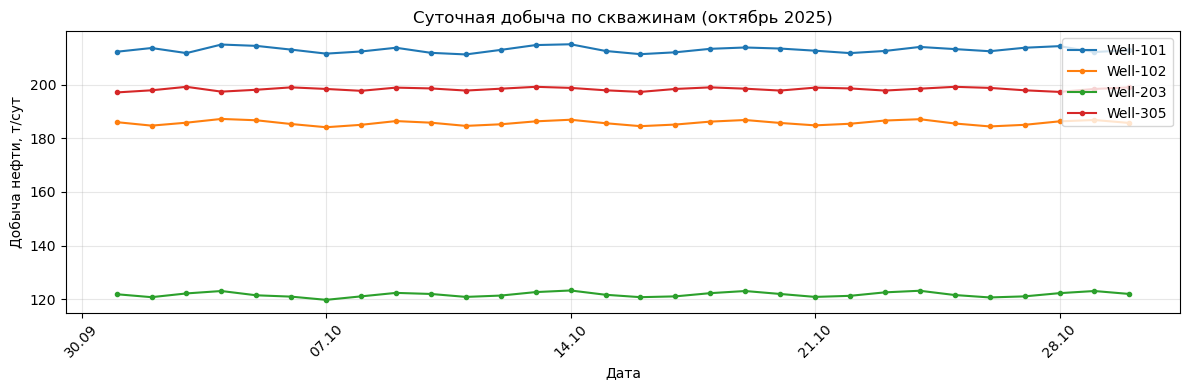

In [7]:
fig, ax = plt.subplots(figsize=(12, 4))

for well_name, group in df_clean.groupby('name'):
    group_sorted = group.sort_values('date')
    ax.plot(group_sorted['date'], group_sorted['oil_ton'], marker='o',
            markersize=3, label=well_name)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.xticks(rotation=45)
ax.set_xlabel('Дата')
ax.set_ylabel('Добыча нефти, т/сут')
ax.set_title('Суточная добыча по скважинам (октябрь 2025)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('chart_01_production_timeline.png', dpi=150)
plt.show()

### 7.2 Bar chart — топ скважин по суммарной добыче

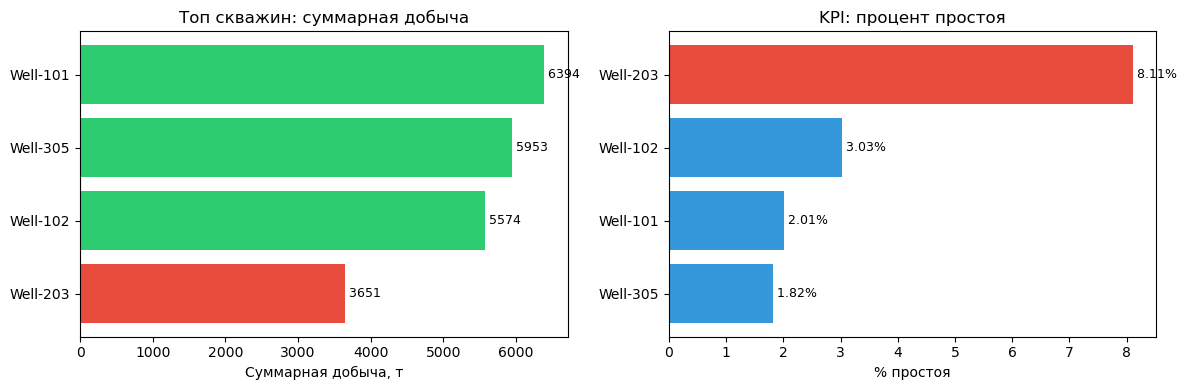

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Суммарная добыча
kpi_sorted_total = kpi.sort_values('total_oil_ton', ascending=True)
axes[0].barh(kpi_sorted_total['name'], kpi_sorted_total['total_oil_ton'],
             color=['#e74c3c' if v == kpi_sorted_total['total_oil_ton'].min() else '#2ecc71'
                    for v in kpi_sorted_total['total_oil_ton']])
axes[0].set_xlabel('Суммарная добыча, т')
axes[0].set_title('Топ скважин: суммарная добыча')
for i, v in enumerate(kpi_sorted_total['total_oil_ton']):
    axes[0].text(v, i, f' {v:.0f}', va='center', fontsize=9)

# Процент простоя
kpi_sorted_dt = kpi.sort_values('downtime_pct', ascending=True)
axes[1].barh(kpi_sorted_dt['name'], kpi_sorted_dt['downtime_pct'],
             color=['#e74c3c' if v == kpi_sorted_dt['downtime_pct'].max() else '#3498db'
                    for v in kpi_sorted_dt['downtime_pct']])
axes[1].set_xlabel('% простоя')
axes[1].set_title('KPI: процент простоя')
for i, v in enumerate(kpi_sorted_dt['downtime_pct']):
    axes[1].text(v, i, f' {v:.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('chart_02_well_kpi.png', dpi=150)
plt.show()

### 7.3 Heatmap — давление vs дебит

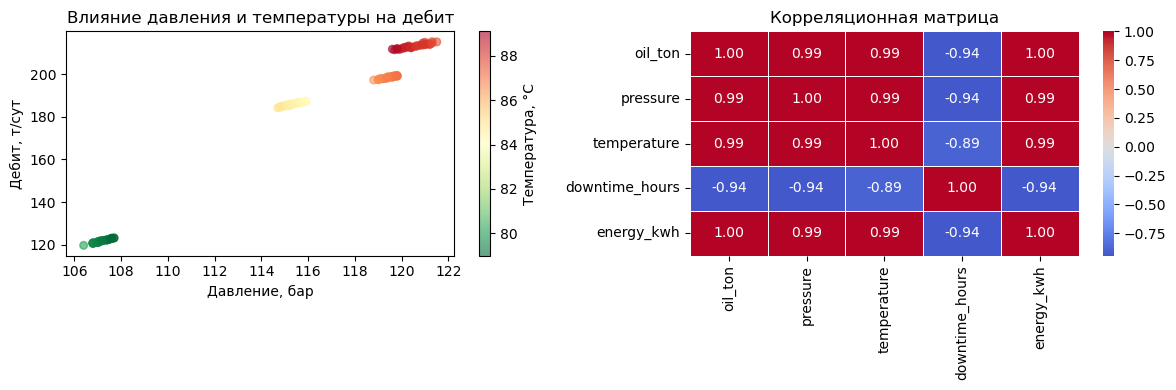

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scatter: давление vs дебит
scatter = axes[0].scatter(
    df_clean['pressure'], df_clean['oil_ton'],
    c=df_clean['temperature'], cmap='RdYlGn_r',
    alpha=0.6, s=30
)
plt.colorbar(scatter, ax=axes[0], label='Температура, °C')
axes[0].set_xlabel('Давление, бар')
axes[0].set_ylabel('Дебит, т/сут')
axes[0].set_title('Влияние давления и температуры на дебит')

# Heatmap корреляций
cols = ['oil_ton', 'pressure', 'temperature', 'downtime_hours', 'energy_kwh']
corr = df_clean[cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1], center=0, linewidths=0.5)
axes[1].set_title('Корреляционная матрица')

plt.tight_layout()
plt.savefig('chart_03_heatmap.png', dpi=150)
plt.show()

## 8. Вывод по заданию 1

In [10]:
total_oil = df_clean['oil_ton'].sum()
avg_daily = daily['total_oil_ton'].mean()
corr_pressure = df_clean['pressure'].corr(df_clean['oil_ton'])
corr_temp     = df_clean['temperature'].corr(df_clean['oil_ton'])

print('=' * 50)
print('ИТОГИ — Аналитика добычи')
print('=' * 50)
print(f'Суммарная добыча за период:  {total_oil:,.0f} т')
print(f'Средняя суточная добыча:     {avg_daily:.1f} т')
print(f'Лучшая скважина:             {best["name"]} ({best["avg_oil_ton"]:.1f} т/сут)')
print(f'Наибольший простой:          {kpi.sort_values("downtime_pct",ascending=False).iloc[0]["name"]}')
print(f'Корреляция давление-дебит:   r = {corr_pressure:.3f}')
print(f'Корреляция температура-дебит: r = {corr_temp:.3f}')
print()
print('Вывод: более высокое давление коррелирует с ростом дебита.')
print('Температура имеет умеренную обратную связь с добычей.')

ИТОГИ — Аналитика добычи
Суммарная добыча за период:  21,573 т
Средняя суточная добыча:     719.1 т
Лучшая скважина:             Well-101 (213.2 т/сут)
Наибольший простой:          Well-203
Корреляция давление-дебит:   r = 0.987
Корреляция температура-дебит: r = 0.985

Вывод: более высокое давление коррелирует с ростом дебита.
Температура имеет умеренную обратную связь с добычей.
